# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [ ]:
source('../shared/r_funcs_repro.r')

# figure s7

- kernel: r_env, R 4.1.3
- date: 2024-0-22

## load

In [1]:
library(tidyverse)
library(Seurat)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

outdir <- '../../output/figs7'
create_dir(outdir)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

In [3]:
celltype_map <- list(
    'T_MKI67' = c('T_Prolif')
)

cell_state_map <- list(
    'cytotoxic' = c('CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK', 'CD8_KLRB1'),
    'exhausted' = c('CD4_CXCL13', 'CD8_CXCL13', 'CD8_TYMS', 'T_MKI67', 'Treg_TNFRSF4'),
    'dying' = c('T_Mito'),
    'others' = c('CD4_KLRB1', 'CD8_CD74', 'CD8_IFIT1', 'T_IL7R', 'T_Ribo', 'Treg_LTB')
)
cell_state_order <- c('cytotoxic', 'exhausted', 'dying', 'others')
cell_state_color <- c('exhausted' = '#023fa5', 'cytotoxic' = 'red', 
                      'dying' = '#bb7784', 'others' = '#ff9639')
# Restored from paper_ii/jupyter_nb_legacy_20260714/figs7.ipynb
ctype_colors <- c(
    CD8_ANXA1 = '#8C0439', CD8_CCL5 = '#A12253', CD8_CX3CR1 = '#B6416D', CD8_FOS = '#CC6088',
    CD8_GZMK = '#E17FA2', CD8_KLRB1 = '#F79EBD', CD4_CXCL13 = '#003CA5', CD8_CXCL13 = '#2F5DB1',
    CD8_TYMS = '#5E7FBD', T_MKI67 = '#8DA1C9', Treg_TNFRSF4 = '#BDC3D6', T_Mito = '#7B7D7B',
    CD4_KLRB1 = '#DF9608', CD8_CD74 = '#E2A22E', CD8_IFIT1 = '#E5AE54', T_IL7R = '#E8BA7A',
    T_Ribo = '#EBC6A0', Treg_LTB = '#EFD3C6'
)


## s7a: TCR sharing diff (R vs NR)

In [4]:
f_node <- '../../data/figures/fig3/fig3b-net_tcr_sharing-node_info.tsv'
f_edge_r_pre <- '../../data/stage4/a03_tcr/net_vlz_old/net_good_Baseline_edge.csv'
f_edge_r_post <- '../../data/stage4/a03_tcr/net_vlz_old/net_good_Treat_edge.csv'
f_edge_pr_pre <- '../../data/stage4/a03_tcr/net_vlz_old/net_poor_Baseline_edge.csv'
f_edge_pr_post <- '../../data/stage4/a03_tcr/net_vlz_old/net_poor_Treat_edge.csv'

# node info
df_node <- read_tsv(f_node, show_col_types = F) %>% 
    mutate(node_type = factor(node_type, levels = cell_state_order))

In [5]:
# pre: R vs NR
df <- cal_edge_weight_diff(a = read_csv(f_edge_r_pre, show_col_types = F), 
                           b = read_csv(f_edge_pr_pre, show_col_types = F)) %>% 
    mutate(wtype = if_else(weight.diff > 0, 'R > NR', 'R < NR'),
           comp_type = 'Pre-treatment: R vs NR')
# add post R vs NR
df <- cal_edge_weight_diff(a = read_csv(f_edge_r_post, show_col_types = F), 
                           b = read_csv(f_edge_pr_post, show_col_types = F)) %>% 
    mutate(wtype = if_else(weight.diff > 0, 'R > NR', 'R < NR'),
           comp_type = 'Post-treatment: R vs NR') %>%
    rbind.data.frame(df)
df %>% write_tsv(str_glue('{outdir}/figs7a-edge_info-r_vs_nr.tsv'))

2026-07-18 18:10:08.263704 INFO::a(25) - b(30) => 31 diff edges.
2026-07-18 18:10:08.347349 INFO::a(24) - b(45) => 47 diff edges.


Loading required package: ggrepel



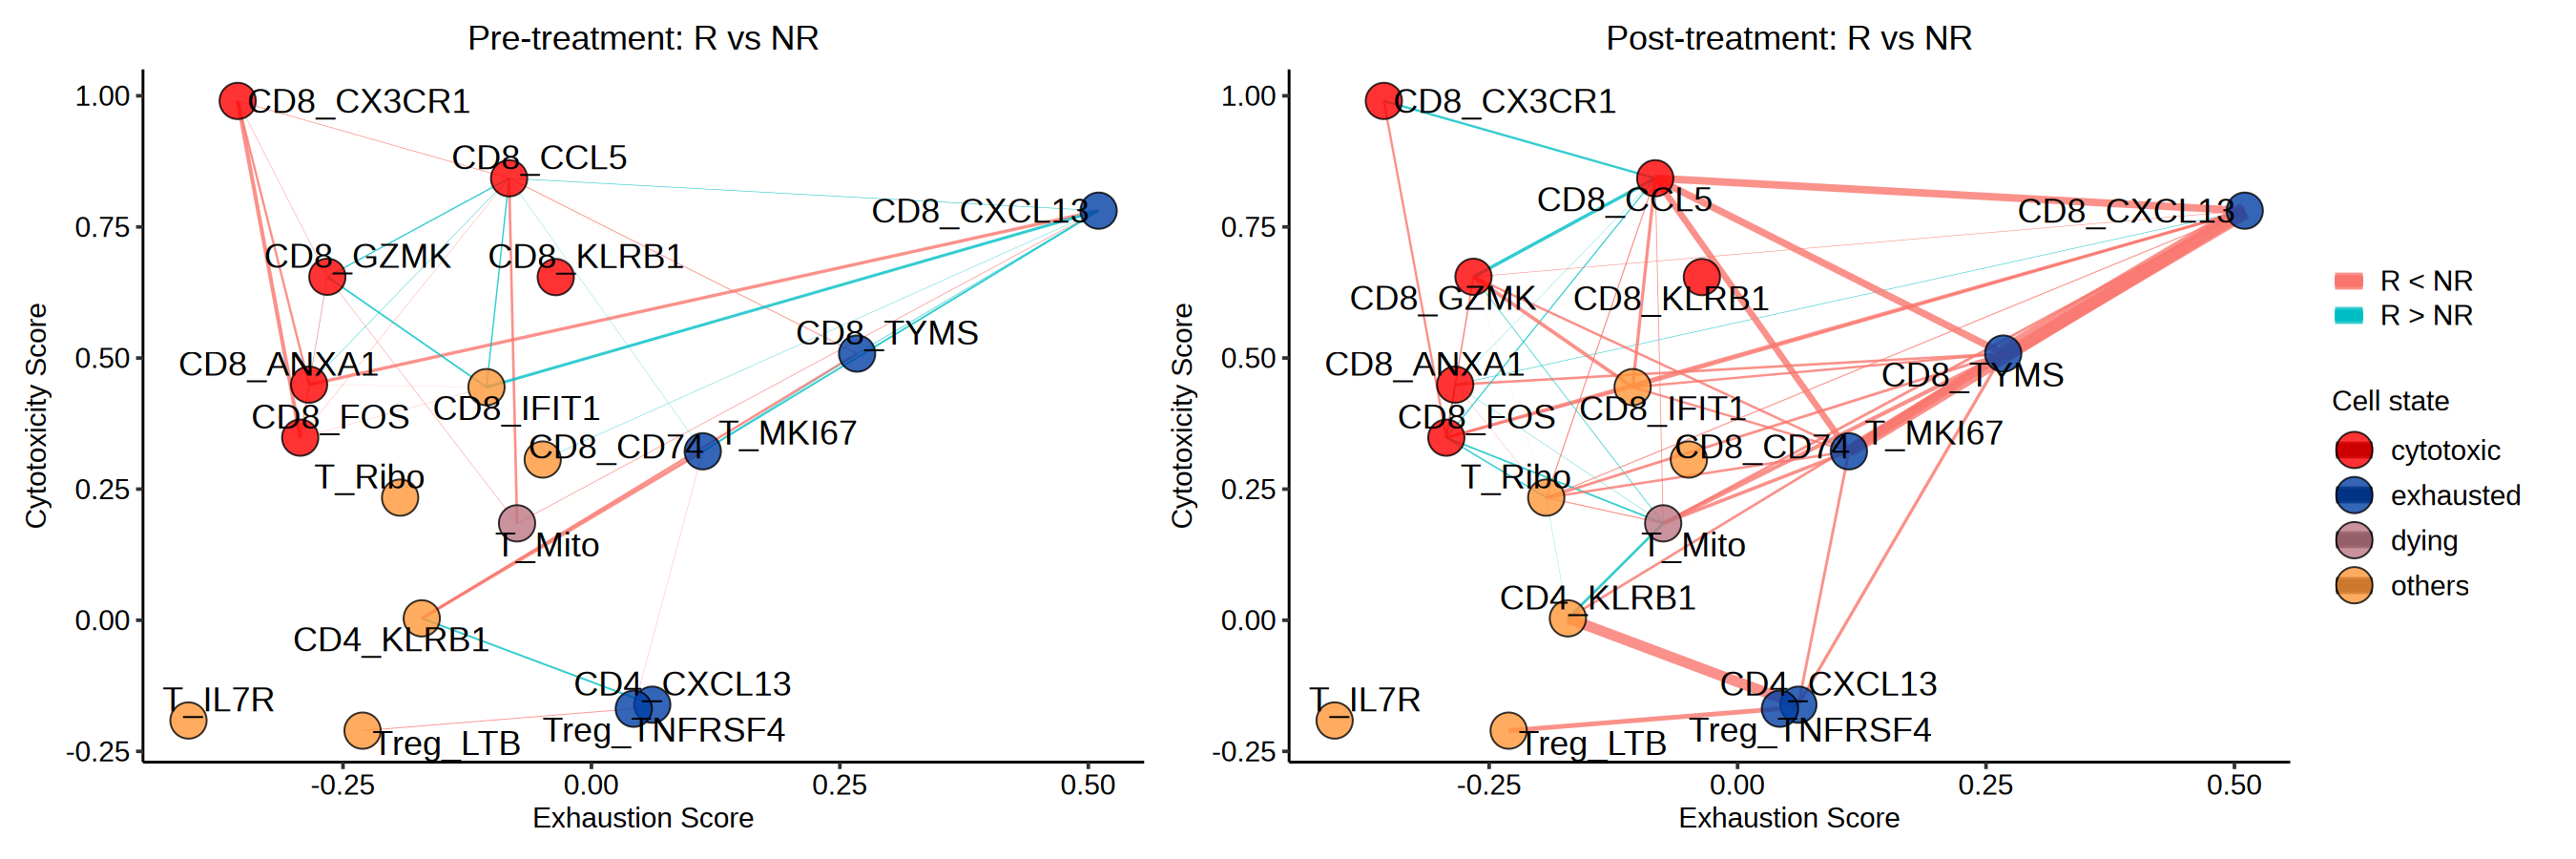

In [6]:
df <- read_tsv(str_glue('{outdir}/figs7a-edge_info-r_vs_nr.tsv'), show_col_types = F)
p_ls <- lapply(X = c('Pre-treatment: R vs NR', 'Post-treatment: R vs NR'), FUN = function(ctype) {
    df_edge <- filter(df, comp_type == ctype)
    p <- exhau_cyto_netplot2(df_node = df_node, df_edge = df_edge, pt_fill = 'node_type', edge_color = 'wtype') +
        scale_fill_manual(values = cell_state_color) +
        labs(fill = 'Cell state', title = ctype, color = '') +
        theme_pubr(base_size = 14) +
        theme(plot.title = element_text(hjust = 0.5),
              legend.position = 'right', 
              legend.text = element_text(size = 14),
              legend.title = element_text(size = 14))
    return(p)
})
p_ls[[1]] <- p_ls[[1]] + theme(legend.position = 'none')
p <- wrap_plots(p_ls)
df_node %>% write_tsv(str_glue('{outdir}/figs7a-node_info-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs7a-net_tcr_sharing-r_vs_nr.pdf'),
       plot = p, width = 18, height = 6)
jp_opt(wd = 18, hg = 6)
print(p)

## s7b: select clones in umap space (require data from GEO)

### prepare

In [7]:
# include all RNA cells (non-TCR-RNA shared cells with NA clonotype)
f_expand <- '../../data/stage4/a03_tcr/expansion/clone_expand_info_per_cell.csv'
f_obj <- '../../data/stage4/a01_data/seuobj/t.rds'

In [ ]:
scrna <- readRDS(f_obj)

In [ ]:
# rename cell types
scrna$celltype <- scrna$subtype
for (nm in names(celltype_map)) {
    scrna$celltype[scrna$subtype %in% celltype_map[[nm]]] <- nm
}
table(scrna$celltype)
# rename sample type
scrna$timepoint <- scrna$sample_type
scrna$timepoint[scrna$sample_type == 'Baseline'] <- 'pre'
scrna$timepoint[scrna$sample_type == 'Treat'] <- 'post'
scrna$timepoint <- factor(scrna$timepoint, levels = c('pre', 'post'))

In [ ]:
cell_clone_info <- read_csv(f_expand, show_col_types = F) %>%
    filter(!is.na(clonotype))  # RNA & TCR cells
loginfo('total %g RNA & TCR cells', nrow(cell_clone_info))

2024-02-28 20:42:52 INFO::total 205824 RNA & TCR cells


### contracted exhausted, R

span more to less

In [ ]:
show_ctypes <- c('T_MKI67', 'CD8_CXCL13', 'CD8_TYMS', 'CD8_CXCL13', 'T_Mito')
select_clone <- 'TRAV12-2;TRBV9_;TRBD1_TRAJ23;TRBJ1-5_TRA:CAVTDNQGGKLIF;TRB:CASSVTGGRGQPQHF_P21'
title_str <- 'Clone 1 (R, contracted in exhausted clusters)'

In [ ]:
cells <- cell_clone_info %>% 
    filter(clonotype == select_clone) %>% 
    pull(barcode)
loginfo('total %g cells of selected clone', length(cells))

2024-02-28 20:59:46 INFO::total 32 cells of selected clone


In [ ]:
scrna$mylabel <- scrna$celltype
scrna$mylabel[!(scrna$celltype %in% show_ctypes)] <- ' '
p <- DimPlot(object = scrna, cells.highlight = cells, group.by = 'mylabel', split.by = 'timepoint', label = T) 
p$data$celltype <- scrna@meta.data[rownames(p$data), 'celltype']
p <- p + 
    geom_point(data = p$data[cells, ], aes(UMAP_1, UMAP_2, color = celltype), size = 2, alpha = 0.8) +
    scale_color_manual(values = ctype_colors, na.value = 'lightgray') +
    ggtitle(title_str) +
    theme(legend.position = 'none')
p$data$selected_clone <- rownames(p$data) %in% cells
write_plot_source_data(p, str_glue('{outdir}/figs7b-exhau_contract-R-umap-selected_clone-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs7b-exhau_contract-R-umap-selected_clone.pdf'), 
       plot = p, width = 7, height = 4)
jp_opt(wd = 7, hg = 4)
print(p)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


### contracted exhausted, NR

In [ ]:
show_ctypes <- c('T_MKI67', 'CD8_CXCL13', 'CD8_TYMS')
select_clone <- 'TRAV27;TRBV20-1_;TRBD2_TRAJ49;TRBJ2-3_TRA:CAVFTGNQFYF;TRB:CSALAGGIDTQYF_P03'
title_str <- 'Clone 2 (NR, contracted in exhausted clusters)'

In [ ]:
# get cells of selected clones
cells <- cell_clone_info %>% 
    filter(clonotype == select_clone) %>% 
    pull(barcode)
loginfo('total %g cells of selected clone', length(cells))

2024-02-28 21:00:19 INFO::total 113 cells of selected clone


In [ ]:
scrna$mylabel <- scrna$celltype
scrna$mylabel[!(scrna$celltype %in% show_ctypes)] <- ' '
p <- DimPlot(object = scrna, cells.highlight = cells, group.by = 'mylabel', split.by = 'timepoint', label = T) 
p$data$celltype <- scrna@meta.data[rownames(p$data), 'celltype']
p <- p + 
    geom_point(data = p$data[cells, ], aes(UMAP_1, UMAP_2, color = celltype), size = 2, alpha = 0.8) +
    scale_color_manual(values = ctype_colors, na.value = 'lightgray') +
    ggtitle(title_str) +
    theme(legend.position = 'none')
p$data$selected_clone <- rownames(p$data) %in% cells
write_plot_source_data(p, str_glue('{outdir}/figs7b-exhau_contract-NR-umap-selected_clone-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs7b-exhau_contract-NR-umap-selected_clone.pdf'), 
       plot = p, width = 7, height = 4)
jp_opt(wd = 7, hg = 4)
print(p)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


### expanded cytotoxic, R

In [ ]:
show_ctypes <- c('CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK')
select_clone <- 'TRAV12-1;TRBV9_;_TRAJ39;TRBJ2-6_TRA:CVVNHAGNMLTF;TRB:CASSVEASGANVLTF_P26'
title_str <- 'Clone 3 (R, expanded in cytotoxic clusters)'

In [ ]:
# get cells of selected clones
cells <- cell_clone_info %>% 
    filter(clonotype == select_clone) %>% 
    pull(barcode)
loginfo('total %g cells of selected clone', length(cells))

2024-02-28 21:00:25 INFO::total 90 cells of selected clone


In [ ]:
scrna$mylabel <- scrna$celltype
scrna$mylabel[!(scrna$celltype %in% show_ctypes)] <- ' '
p <- DimPlot(object = scrna, cells.highlight = cells, group.by = 'mylabel', split.by = 'timepoint', label = T) 
p$data$celltype <- scrna@meta.data[rownames(p$data), 'celltype']
p <- p + 
    geom_point(data = p$data[cells, ], aes(UMAP_1, UMAP_2, color = celltype), size = 2, alpha = 0.8) +
    scale_color_manual(values = ctype_colors, na.value = 'lightgray') +
    ggtitle(title_str) +
    theme(legend.position = 'none')
p$data$selected_clone <- rownames(p$data) %in% cells
write_plot_source_data(p, str_glue('{outdir}/figs7b-cyto_expand-R-umap-selected_clone-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs7b-cyto_expand-R-umap-selected_clone.pdf'), 
       plot = p, width = 7, height = 4)
jp_opt(wd = 7, hg = 4)
print(p)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


### expanded cytotoxic, NR

In [ ]:
show_ctypes <- c('CD8_ANXA1', 'CD8_CCL5', 'CD8_FOS', 'CD8_GZMK', 'CD8_CXCL13', 'CD8_TYMS', 'T_MKI67')
select_clone <- 'TRAV20;TRBV4-2_;_TRAJ43;TRBJ2-7_TRA:CAVRGDNNDMRF;TRB:CASSHGTYSYEQYF_P20'
title_str <- 'Clone 4 (NR, expanded in cytotoxic clusters)'

In [ ]:
# get cells of selected clones
cells <- cell_clone_info %>% 
    filter(clonotype == select_clone) %>% 
    pull(barcode)
loginfo('total %g cells of selected clone', length(cells))

2024-02-28 21:00:31 INFO::total 149 cells of selected clone


In [ ]:
scrna$mylabel <- scrna$celltype
scrna$mylabel[!(scrna$celltype %in% show_ctypes)] <- ' '
p <- DimPlot(object = scrna, cells.highlight = cells, group.by = 'mylabel', split.by = 'timepoint', label = T) 
p$data$celltype <- scrna@meta.data[rownames(p$data), 'celltype']
p <- p + 
    geom_point(data = p$data[cells, ], aes(UMAP_1, UMAP_2, color = celltype), size = 2, alpha = 0.8) +
    scale_color_manual(values = ctype_colors, na.value = 'lightgray') +
    ggtitle(title_str) +
    theme(legend.position = 'none')
p$data$selected_clone <- rownames(p$data) %in% cells
write_plot_source_data(p, str_glue('{outdir}/figs7b-cyto_expand-NR-umap-selected_clone-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs7b-cyto_expand-NR-umap-selected_clone.pdf'), 
       plot = p, width = 7, height = 4)
jp_opt(wd = 7, hg = 4)
print(p)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
